# ADOM
## Multimodalność - model CLIP (2021)
Kamil Bilski, Dawid Cybulski, Bartosz Socki, Oliwier Kniażewski; 6.06

## Omowienie metody (CLIP)
CLIP (Contrastive Language-Image Pretraining) to metoda uczenia multimodalnego, ktora mapuje obrazy i tekst do wspolnej przestrzeni embeddingow. Dzieki temu mozna wykonywac klasyfikacje zero-shot: etykiety opisuje sie tekstem (promptami), a nastepnie porownuje podobienstwo embeddingow obrazu i tekstu. W praktyce CLIP dobrze sprawdza sie w rozpoznawaniu obiektow bez dodatkowego trenowania na docelowym zbiorze, o ile opisy sa trafne.

Wieksze omowienia i zasoby:
- https://openai.com/research/clip
- https://arxiv.org/abs/2103.00020
- https://github.com/openai/CLIP
- https://github.com/mlfoundations/open_clip

## Omowienie wykorzystanej implementacji
Notebook testuje CLIP na MNIST w trybie zero-shot z rozbudowanym ensemblingiem promptow. Dla kazdej cyfry tworzone sa liczne warianty opisow (szablony i warianty nazw), a wektory tekstowe sa uzywane do budowy wag zero-shot. W ewaluacji obrazy sa przetwarzane batchowo, obliczane sa embeddingi obrazu i porownywane z wieloma promptami; nastepnie wybierane jest uogolnione podobienstwo (srednia top-k), co stabilizuje wyniki.

Notebook zawiera tez inspekcje pojedynczego przykladu (z odwracaniem kolorow dla lepszej zgodnosci z CLIP) oraz sekcje linear probing: zamrozone embeddingi obrazu z CLIP sa uzyte jako cechy dla regresji logistycznej, co pozwala sprawdzic, ile informacji o cyfrach jest w samym koderze obrazu.

### 3. CLIP + MNIST: eksperymenty zero-shot na datasecie MNIST z ręcznie napisanymi cyframi
Ten notatnik pozwala porownywac modele CLIP na cyfrach MNIST z roznymi promptami tekstowymi.
Uruchamiaj komorki od gory do dolu. Zmien parametry w nastepnej komorce i uruchom eksperyment ponownie.
Eksperyment wymaga dość dużej mocy obliczeniowej do obliczeń, stąd najlepiej uruchomić go poprzez np. Kaggle

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gmafr174
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gmafr174
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8e5eca4155335458511d0b788b879850f477a20826ad0356fbc24a2a75a4c1fa
  Stored in directory: /tmp/pip-ephem-wheel-cache-dg7_jjex/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import random
from pathlib import Path
import PIL.ImageOps
import matplotlib.pyplot as plt
import numpy as np
import torch
import clip
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
 )
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Wykryte urzadzenie: {DEVICE.upper()}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# lista dostepnych modeli CLIP
MODELS = [
    "RN50",
    "RN101",
    "RN50x4",
    "RN50x16",
    "RN50x64",
    "ViT-B/32",
    "ViT-B/16",
    "ViT-L/14",
    "ViT-L/14@336px",
]

# krotkie opisy modeli CLIP
MODEL_DESCRIPTIONS = {
    "RN50": "Backbone ResNet-50; najszybszy i najmniejszy w rodzinie RN.",
    "RN101": "Backbone ResNet-101; wieksza pojemnosc niz RN50.",
    "RN50x4": "Szerszy RN50; lepsza jakosc, wolniejszy.",
    "RN50x16": "Znacznie szerszy RN50; wysoka jakosc, duzy koszt obliczen.",
    "RN50x64": "Najwiekszy wariant RN; najwyzszy koszt obliczen.",
    "ViT-B/32": "Vision Transformer base z patchami 32px; dobry kompromis szybkosci i jakosci.",
    "ViT-B/16": "Vision Transformer base z patchami 16px; bardziej dokladny, wolniejszy.",
    "ViT-L/14": "Duzy ViT z patchami 14px; wysoka jakosc, duzy koszt obliczen.",
    "ViT-L/14@336px": "ViT-L/14 z wejsciem 336px; najlepsza jakosc, najwolniejszy.",
}

Wykryte urzadzenie: CUDA


In [ ]:
MODEL_NAME = "ViT-L/14"  # wybierz z MODELS
NUM_SAMPLES = None  # ustaw None, aby ocenic caly test
BATCH_SIZE = 64

# katalog na dane MNIST z numerami
MNIST_ROOT = Path.cwd().parent / "data"

DATASET_SPLIT = "test"  # MNIST ma tylko train/test

### Ensembling promptow i usrednianie osadzen
W CLIP jedno haslo tekstowe (prompt) potrafi mocno zmienic wynik, bo model jest wrazliwy na sformulowanie opisu. Zamiast polegac na jednym zdaniu, tworzymy wiele wariantow opisujacych ta sama klase (np. „a photo of the digit 7”, „a handwritten digit 7”, „a sketch of the digit 7”). Dla kazdego promptu liczymy wektor tekstowy (embedding), a nastepnie usredniamy je do jednego, stabilniejszego wektora klasy. To nazywamy ensemblingiem promptow — zmniejsza on przypadkowosc i sprawia, ze klasy sa opisywane bardziej „srednio” i mniej podatnie na pojedynczy nietrafiony prompt.

Podobnie dziala ensembling nazw klas: zamiast jednej nazwy („seven”) uzywamy wielu wariantow („seven”, „7”, „digit seven”, „number 7”). Dzieki temu embedding klasy lepiej reprezentuje realne dane (np. cyfry pisane odręcznie), co zwykle poprawia stabilnosc i jakosc predykcji.



In [5]:
# slowne nazwy cyfr
NUMBERS_WRITTEN = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
DIGITS_WRITTEN = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

# 36 szablonow promptow (ensembling)
PROMPT_TEMPLATES = [
    "a photo of a handwritten digit {name}",
    "a photo of the handwritten digit {name}",
    "a photo of a handwritten {name}",
    "a photo of the digit {name}",
    "a photo of the number {name}",
    "a grayscale photo of the handwritten digit {name}",
    "a black and white photo of the digit {name}",
    "a close-up photo of a handwritten digit {name}",
    "a cropped photo of the digit {name}",
    "a low resolution photo of the digit {name}",
    "a blurry photo of the digit {name}",
    "a clean photo of the handwritten digit {name}",
    "a dirty photo of the digit {name}",
    "a photo of a small handwritten digit {name}",
    "a photo of a large handwritten digit {name}",
    "a sketch of the digit {name}",
    "a drawing of the digit {name}",
    "a doodle of the digit {name}",
    "a pixelated photo of the digit {name}",
    "a photo of the digit {name} on a white background",
    "a photo of the digit {name} on a black background",
    "a photo of the digit {name} on paper",
    "a photo of the digit {name} written in pencil",
    "a photo of the digit {name} written in pen",
    "a photo of the digit {name} written in marker",
    "a photo of the digit {name} in a notebook",
    "a photo of the digit {name} in a workbook",
    "a scanned photo of the digit {name}",
    "a centered photo of the digit {name}",
    "a high contrast photo of the digit {name}",
    "a low contrast photo of the digit {name}",
    "a photo of a single handwritten digit {name}",
    "a photo of the handwritten number {name}",
    "a close-up photo of the digit {name}",
    "a photo of the digit {name} written by hand",
    "a grayscale photo of the digit {name}",
]

# prompty per-klasa (uzupelniaj tylko wybrane cyfry)
SPECIAL_CLASS_TEMPLATES = {
    1: [
        "a handwritten digit 1, a single vertical stroke",
        "a handwritten digit 1 without a crossbar",
        "a handwritten digit 1 with a serif",
        "a handwritten digit 1 (vertical line)",
        "a thin handwritten digit 1",
        "a tall handwritten digit 1",
    ],
    7: [
        "a handwritten digit 7 with a crossbar",
        "a handwritten digit 7 without a crossbar",
        "a handwritten digit 7 (angled top)",
        "a handwritten digit 7 with a horizontal bar",
    ],
}

# opcjonalny wybor podzbioru szablonow (np. 7 najlepszych)
#TEMPLATE_SELECTION = [0, 3, 4, 6, 7, 8, 11, 15, 16, 31]
TEMPLATE_SELECTION = None

In [6]:
# Pomocnicze funkcje do skladania promptow i ewaluacji
def select_templates(all_templates, selection):
    # Uzywa pelnej listy, jesli brak selekcji indeksow
    if not selection:
        return all_templates
    return [all_templates[i] for i in selection]

# warianty nazw klas (ensembling po nazwach)
def build_class_name_variants():
    variants = []
    for word, digit in zip(NUMBERS_WRITTEN, DIGITS_WRITTEN):
        variants.append([
            word,
            digit,
            f"digit {word}",
            f"number {word}",
            f"handwritten {word}",
            f"handwritten digit {word}",
            f"written {word}",
            f"digit {digit}",
            f"number {digit}",
            f"handwritten {digit}",
            f"handwritten digit {digit}",
            f"written {digit}",
        ])
    return variants

def build_prompt_texts(name_variants, templates, special_templates):
    # Laczy szablony bazowe z wariantami nazw oraz promptami per-klasa
    texts = []
    for name in name_variants:
        texts.extend([template.format(name=name) for template in templates])
    if special_templates:
        texts.extend([template.format(name=name_variants[0]) for template in special_templates])
    return texts

# buduje wagi zero-shot przez usrednianie osadzen dla promptow i nazw
# model: zaladowany model CLIP (uzywany do encode_text)
# class_name_variants: lista wariantow nazw dla kazdej klasy (np. "one", "1", "digit one")
# templates: wybrane szablony promptow bazowych
# device: urzadzenie dla tokenow i obliczen ("cpu" lub "cuda")
def zeroshot_classifier(model, class_name_variants, templates, device):
    with torch.no_grad():
        zeroshot_weights_list = []
        
        for class_idx, name_variants in enumerate(class_name_variants):
            texts = build_prompt_texts(
                name_variants,
                templates,
                SPECIAL_CLASS_TEMPLATES.get(class_idx, []),
            )
            
            # Zamiana promptów na tokeny i wektory
            text_tokens = clip.tokenize(texts).to(device)
            class_embeddings = model.encode_text(text_tokens).float()
            
            # Normalizacja wektorów
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            
            # USUNIĘTE: class_embedding = class_embeddings.mean(dim=0)
            # Zamiast uśredniać, zachowujemy całą macierz kształtu (liczba_promptów, embedding_dim)
            zeroshot_weights_list.append(class_embeddings)
            
    # Zwracamy listę tensorów, ponieważ klasy mogą mieć różną liczbę promptów
    return zeroshot_weights_list

# funkcja pobierajaca MNIST. Wybiera 'train' i pobiera dane jesli brak
def get_mnist(split):
    is_train = split == "train"
    return datasets.MNIST(root=MNIST_ROOT, train=is_train, download=True)

# wlasny collate dla DataLoader. Rozdziela obrazy i etykiety.
def pil_collate(batch):
    images, targets = zip(*batch)
    return list(images), torch.tensor(targets)

# tworzy DataLoader
def make_loader(dataset, num_samples, batch_size):
    if num_samples is None or num_samples >= len(dataset):
        subset = dataset
    else:
        indices = np.random.choice(len(dataset), size=num_samples, replace=False)
        subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=False, collate_fn=pil_collate)

# glowna ewaluacja CLIP (zero-shot z ensemblingiem promptow)
# model: zaladowany model CLIP (encode_image)
# preprocess: transformacja obrazu zgodna z CLIP
# zeroshot_weights_list: lista wag
# loader: DataLoader z obrazami i etykietami
# device: urzadzenie obliczen
def run_clip_eval(model, preprocess, zeroshot_weights_list, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, targets in loader:
            processed_images = [preprocess(img.convert("RGB")) for img in images]
            image_inputs = torch.stack(processed_images).to(device)

            # Ekstrakcja i normalizacja cech obrazu. Kształt: (batch_size, embedding_dim)
            image_features = model.encode_image(image_inputs).float()
            image_features /= image_features.norm(dim=-1, keepdim=True)

            batch_logits = []

            K = 5
            
            for class_embeddings in zeroshot_weights_list:
                similarity = 100.0 * image_features @ class_embeddings.T
    
                # Zabezpieczenie przed zbyt mala liczba promptow
                current_k = min(K, similarity.shape[-1])
                
                # Wyciągamy K najwyższych wartości podobieństwa (odrzucamy ich indeksy)
                topk_values, _ = similarity.topk(current_k, dim=-1)
                
                # Uśredniamy te K najlepszych wartości
                mean_topk_sim = topk_values.mean(dim=-1)
                
                batch_logits.append(mean_topk_sim)

            # Składamy wyniki z powrotem w tensor kształtu (batch_size, liczba_klas)
            logits_per_image = torch.stack(batch_logits, dim=1)
            
            # Standardowa kalkulacja prawdopodobieństw i predykcji
            probs = logits_per_image.softmax(dim=-1).cpu().numpy()
            preds = probs.argmax(axis=-1)

            all_preds.extend(preds.tolist())
            all_targets.extend(targets.tolist())
            all_probs.append(probs)

    return np.array(all_preds), np.array(all_targets), np.vstack(all_probs)

In [7]:
# Podglad promptow dla klasy 1 (pierwsze 20)
templates = select_templates(PROMPT_TEMPLATES, TEMPLATE_SELECTION)
class_name_variants = build_class_name_variants()
preview_texts = build_prompt_texts(
    class_name_variants[1],
    templates,
    SPECIAL_CLASS_TEMPLATES.get(1, []),
)

print(f"Liczba promptow dla klasy 1: {len(preview_texts)}")
for text in preview_texts[:20]:
    print("-", text)

Liczba promptow dla klasy 1: 438
- a photo of a handwritten digit one
- a photo of the handwritten digit one
- a photo of a handwritten one
- a photo of the digit one
- a photo of the number one
- a grayscale photo of the handwritten digit one
- a black and white photo of the digit one
- a close-up photo of a handwritten digit one
- a cropped photo of the digit one
- a low resolution photo of the digit one
- a blurry photo of the digit one
- a clean photo of the handwritten digit one
- a dirty photo of the digit one
- a photo of a small handwritten digit one
- a photo of a large handwritten digit one
- a sketch of the digit one
- a drawing of the digit one
- a doodle of the digit one
- a pixelated photo of the digit one
- a photo of the digit one on a white background


In [8]:
# Walidacja konfiguracji i przygotowanie promptow
if MODEL_NAME not in MODELS:
    raise ValueError(f"MODEL_NAME musi byc jednym z: {MODELS}")

templates = select_templates(PROMPT_TEMPLATES, TEMPLATE_SELECTION)
class_name_variants = build_class_name_variants()
labels_display = [str(i) for i in range(10)]

# Dane i loader
dataset = get_mnist(DATASET_SPLIT)
loader = make_loader(dataset, NUM_SAMPLES, BATCH_SIZE)

# Zaladowanie modelu i podstawowe parametry
model, preprocess = clip.load(MODEL_NAME, device=DEVICE)
model.to(DEVICE).eval()
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

# Budowa wag zero-shot i ewaluacja
zeroshot_weights = zeroshot_classifier(model, class_name_variants, templates, DEVICE)
preds, targets, probs = run_clip_eval(model, preprocess, zeroshot_weights, loader, DEVICE)
print(f"Liczba ocenionych probek: {len(targets)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]
100%|████████████████████████████████████████| 890M/890M [00:09<00:00, 102MiB/s]


Model parameters: 427,616,513
Input resolution: 224
Context length: 77
Vocab size: 49408
Liczba ocenionych probek: 10000


## Metryki i analiza
Accuracy, confusion matrix, precision i recall dla kazdej cyfry.

Accuracy: 0.6811


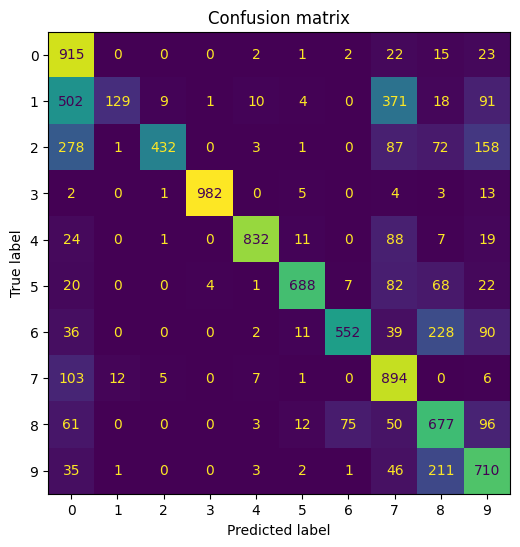

Cyfra 0: precision=0.463, recall=0.934, f1=0.619, support=980
Cyfra 1: precision=0.902, recall=0.114, f1=0.202, support=1135
Cyfra 2: precision=0.964, recall=0.419, f1=0.584, support=1032
Cyfra 3: precision=0.995, recall=0.972, f1=0.983, support=1010
Cyfra 4: precision=0.964, recall=0.847, f1=0.902, support=982
Cyfra 5: precision=0.935, recall=0.771, f1=0.845, support=892
Cyfra 6: precision=0.867, recall=0.576, f1=0.692, support=958
Cyfra 7: precision=0.531, recall=0.870, f1=0.660, support=1028
Cyfra 8: precision=0.521, recall=0.695, f1=0.596, support=974
Cyfra 9: precision=0.578, recall=0.704, f1=0.635, support=1009

Pelny raport klasyfikacji:
              precision    recall  f1-score   support

           0      0.463     0.934     0.619       980
           1      0.902     0.114     0.202      1135
           2      0.964     0.419     0.584      1032
           3      0.995     0.972     0.983      1010
           4      0.964     0.847     0.902       982
           5      0.93

In [9]:
# Metryki: accuracy, confusion matrix, precision, recall per klasa
acc = accuracy_score(targets, preds)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(targets, preds, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix")
plt.show()

prec, rec, f1, support = precision_recall_fscore_support(
    targets, preds, labels=list(range(10)), zero_division=0
 )
for i in range(10):
    print(
        f"Cyfra {i}: precision={prec[i]:.3f}, recall={rec[i]:.3f}, " # type: ignore
        f"f1={f1[i]:.3f}, support={support[i]}" # type: ignore
    )

print("\nPelny raport klasyfikacji:")
print(classification_report(targets, preds, labels=list(range(10)), digits=3, zero_division=0))

## Inspekcja pojedynczego przykladu
Opcjonalnie: zobacz jeden przyklad i prawdopodobienstwa modelu.

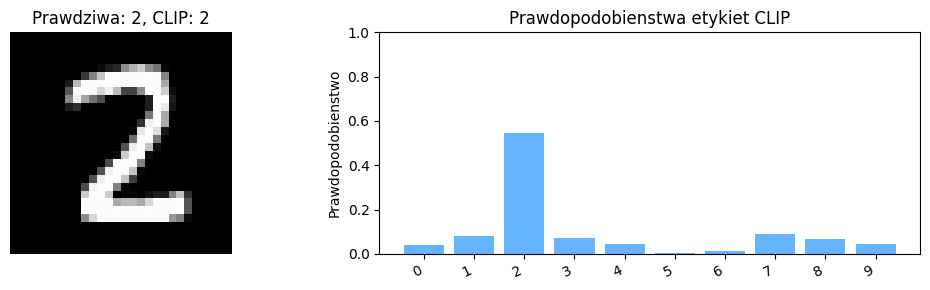

In [10]:
# Inspekcja pojedynczego losowego przykladu
mnist_size = len(dataset)
idx = random.randrange(0, mnist_size)
sample_img, sample_target = dataset[idx]

# DODANE: Inwersja kolorów dla lepszego rozpoznawania przez CLIP
inverted_img = PIL.ImageOps.invert(sample_img.convert("RGB"))
image_input = preprocess(inverted_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    image_feature = model.encode_image(image_input).float()
    image_feature = image_feature / image_feature.norm(dim=-1, keepdim=True)
    
    logits_list = []
    
    for class_embeddings in zeroshot_weights: 
        # class_embeddings ma kształt: (liczba_promptow, embedding_dim)
        similarity = 100.0 * image_feature @ class_embeddings.T
        max_sim, _ = similarity.max(dim=-1)
        logits_list.append(max_sim)
        
    # Składamy wyniki w jeden tensor kształtu (1, 10)
    logits = torch.stack(logits_list, dim=1)
    probs_single = logits.softmax(dim=-1).cpu().numpy()[0]
    pred_idx = int(probs_single.argmax())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray") # Wyświetlamy oryginalny, nieodwrócony obraz dla czytelności
ax1.set_title(f"Prawdziwa: {sample_target}, CLIP: {pred_idx}")
ax1.axis("off")

ax2.bar(range(len(labels_display)), probs_single, color="#66b3ff")
ax2.set_xticks(range(len(labels_display)))
ax2.set_xticklabels(labels_display, rotation=25, ha="right")
ax2.set_ylabel("Prawdopodobienstwo")
ax2.set_ylim(0, 1)
ax2.set_title("Prawdopodobienstwa etykiet CLIP")

plt.tight_layout()
plt.show()

## Wnioski dla CLIP z MNIST
Mimo że CLIP to potężny model wielomodalny trenowany na 400 milionach par danych, jego skuteczność na zbiorze MNIST (zero-shot) jest drastycznie niska (często poniżej 50%, a przy złym prompcie spada do 10-20%). Dla porównania, prosta klasyczna regresja logistyczna osiąga tu ~92%, a sieci CNN ponad 99%.

Tak słabe wyniki mogą wynikać z kilku konkretnych ograniczeń architektury modelu:
- CLIP uczył się na naturalnych zdjęciach o bogatym kontekście (cienie, oświetlenie, tła). Sterylne, czarno-białe cyfry MNIST bez tła są dla niego nienaturalną, "mechaniczną" anomalią, którą warstwy uwagi często traktują jako bezwartościowy szum.
- Pojęcia leksykalne są zbyt ogólnikowe. Słowo (np. "siedem") nie posiada wystarczającej precyzji, aby zamapować w funkcji kosinusowej drobne różnice geometryczne i topograficzne odręcznych krzywizn pętli.
- Model wyewoluował w oparciu o silną wiarę w tekst obecny na obrazach, co czyni go podatnym na "Błąd Abstrakcji" i ataki typograficzne. Kiedy abstrakcyjny symbol arytmetyczny zostaje wyrwany z jakiegokolwiek szerszego kontekstu semantycznego, model traci ramy interpretacyjne i zaczyna zgadywać.  

## 2. Próbkowanie Liniowe (Linear Probing)

### Czym jest Próbkowanie Liniowe?
Próbkowanie liniowe (ang. *linear probing*) to technika polegająca na rezygnacji z klasyfikatora tekstowo-obrazowego na rzecz wykorzystania wewnętrznych struktur modelu jako generatora wektorów reprezentacji głębokiej przestrzeni. W tym paradygmacie zamraża się oryginalne wagi modelu wizyjnego, a na szczycie uzyskanych osadzeń (embeddings) implementuje się i trenuje prostą warstwę klasyfikatora liniowego.

### Co robi poniższy kod?
1. **Ekstrakcja cech wizualnych:** Przepuszcza obrazy z sekcji treningowej oraz testowej zbioru MNIST przez zablokowany koder obrazu CLIP, ekstrahując z nich znormalizowane wektory głębokich reprezentacji.
2. **Trening głowicy liniowej:** Wykorzystuje uzyskane wektory do wytrenowania tradycyjnego modelu regresji logistycznej, który uczy się separacji statystycznej i wyznaczania płaszczyzn decyzyjnych dla 10 klas odręcznych cyfr.
3. **Ewaluacja i porównanie:** Generuje ostateczne predykcje dla zbioru testowego oraz wyświetla pełen raport klasyfikacji, pozwalając na bezpośrednie, empiryczne zweryfikowanie wzrostu skuteczności po odcięciu ograniczeń semantyki języka naturalnego.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import torch

# ekstrakcja wektorów cech z modelu CLIP
def extract_clip_features(loader, model, preprocess, device):
    """
    Przepuszcza obrazy przez koder obrazu CLIP i zwraca wektory cech (embeddings)
    bez udziału kodera tekstu.
    """
    all_features = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            # Preprocess i budowa wejścia
            processed_images = [preprocess(img.convert("RGB")) for img in images]

            image_inputs = torch.stack(processed_images).to(device)

            # Ekstrakcja cech z kodera obrazu
            image_features = model.encode_image(image_inputs).float()
            # Normalizacja wektorów
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            all_features.append(image_features.cpu().numpy())
            all_labels.extend(targets.tolist())

    return np.vstack(all_features), np.array(all_labels)

# Pobranie zbioru treningowego i utworzenie loaderów
print("Przygotowanie zbioru mnist")
train_dataset = get_mnist("train")

train_loader = make_loader(train_dataset, num_samples=10000, batch_size=BATCH_SIZE)

test_loader = loader 

# Ekstrakcja cech głębokich
print("Ekstracja cech dla train")
X_train, y_train = extract_clip_features(train_loader, model, preprocess, DEVICE)
print("Ekstrakcja cech dla test")
X_test, y_test = extract_clip_features(test_loader, model, preprocess, DEVICE)

# Trening klasyfikatora liniowego (Linear Probing)
classifier = LogisticRegression(random_state=SEED, max_iter=1000, C=0.316)
classifier.fit(X_train, y_train)

# Ewaluacja metody Linear Probing
predictions = classifier.predict(X_test)
acc_linear = accuracy_score(y_test, predictions)

print(f"Dokładność (Accuracy): {acc_linear:.4f}")
print("Szczegółowy raport:")
print(classification_report(y_test, predictions, digits=3))

Dokładność (Accuracy): 0.9522
Szczegółowy raport:
              precision    recall  f1-score   support

           0      0.935     0.992     0.962       980
           1      0.925     0.994     0.958      1135
           2      0.913     0.975     0.943      1032
           3      0.994     0.972     0.983      1010
           4      0.977     0.959     0.968       982
           5      0.961     0.963     0.962       892
           6      0.975     0.925     0.949       958
           7      0.964     0.927     0.945      1028
           8      0.944     0.920     0.932       974
           9      0.949     0.890     0.919      1009

    accuracy                          0.952     10000
   macro avg      0.954     0.952     0.952     10000
weighted avg      0.953     0.952     0.952     10000



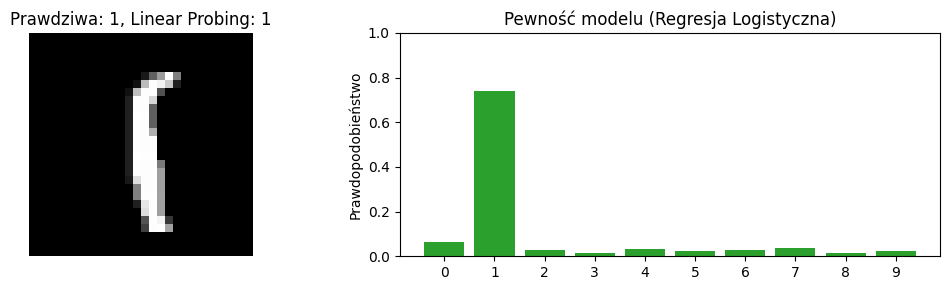

In [13]:
# Losowanie indeksu ze zbioru testowego
idx = random.randrange(0, len(dataset))
sample_img, sample_target = dataset[idx]

# Ekstrakcja cechy dla pojedynczego obrazka za pomocą zamrożonego kodera CLIP
image_input = preprocess(sample_img.convert("RGB")).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    image_feature = model.encode_image(image_input).float()
    # Normalizacja wektora (zgodnie z wcześniejszymi krokami)
    image_feature = image_feature / image_feature.norm(dim=-1, keepdim=True)
    image_feature_np = image_feature.cpu().numpy()

# Predykcja za pomocą wyuczonego modelu regresji logistycznej
pred_idx = classifier.predict(image_feature_np)[0]
probs_single = classifier.predict_proba(image_feature_np)[0]

# Wizualizacja graficzna
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray")
ax1.set_title(f"Prawdziwa: {sample_target}, Linear Probing: {pred_idx}")
ax1.axis("off")

# Rysowanie rozkładu prawdopodobieństwa z regresji logistycznej
ax2.bar(range(10), probs_single, color="#2ca02c")
ax2.set_xticks(range(10))
ax2.set_xticklabels([str(i) for i in range(10)])
ax2.set_ylabel("Prawdopodobieństwo")
ax2.set_ylim(0, 1)
ax2.set_title("Pewność modelu (Regresja Logistyczna)")

plt.tight_layout()
plt.show()

## Wnioski dla Linear Probing z MNIST

Zastosowanie próbkowania liniowego zazwyczaj poprawia wyniki względem trybu zero-shot, jednak ten eksperyment obnaża kolejne, głęboko zakorzenione słabości architektury CLIP w starciu z izolowaną geometrią
- Wytrenowanie warstwy regresji liniowej na zamrożonych osadzeniach wizualnych modelu pozwala odciąć zawodny koder tekstowy . Eliminuje to problem "wąskiego gardła" i niestabilności szablonów, stabilizując predykcję na wyższym poziomie.
- Takie podejście jest kompromisem polegającym na powrocie do uczenia nadzorowanego z użyciem etykiet. Model w ten sposób traci swoją największą zaletę decyzyjną - swoją zdolność do adaptacji w locie.
- Mimo zmiany podejścia i poprawienia wyników klasyfikacji, cechy wyciągnięte z CLIP-a nadal wypadają blado w zestawieniu z architekturą sieci splotowych (CNN), a nawet z podstawową regresją logistyczną na surowych pikselach . Udowadnia to trwalszy defekt: koder obrazu CLIP, ukształtowany ewolucyjnie przez organiczną semantykę internetową, trwale zniekształca obiektywną, dyskryminacyjną optykę i gubi ścisłe relacje pikslowe izolowanych brył.